In [1]:

import pandas as pd
import glob

files = glob.glob("data/raw/*.parquet")
print(f"Found {len(files)} files")

dfs = []
for f in files:
    d = pd.read_parquet(f)
    d['source_file'] = f.split('/')[-1]   # keep provenance, drop before training
    dfs.append(d)
    print(f, d.shape)

df = pd.concat(dfs, ignore_index=True)
print("\nTotal shape:", df.shape)
print("\nColumns:")
print(list(df.columns))

Found 0 files


ValueError: No objects to concatenate

In [2]:
import os
print("Current working directory:", os.getcwd())

Current working directory: /Users/tavle/Desktop/trustsoc-ai/notebooks


In [6]:
print(os.listdir("data/raw"))

FileNotFoundError: [Errno 2] No such file or directory: 'data/raw'

In [4]:
import glob

files = glob.glob("../data/raw/*.parquet")
print(f"Found {len(files)} files")
print(files)

Found 8 files
['../data/raw/DDoS-Friday-no-metadata.parquet', '../data/raw/Bruteforce-Tuesday-no-metadata.parquet', '../data/raw/Botnet-Friday-no-metadata.parquet', '../data/raw/DoS-Wednesday-no-metadata.parquet', '../data/raw/Benign-Monday-no-metadata.parquet', '../data/raw/Infiltration-Thursday-no-metadata.parquet', '../data/raw/Portscan-Friday-no-metadata.parquet', '../data/raw/WebAttacks-Thursday-no-metadata.parquet']


In [2]:
import pandas as pd
import glob

files = glob.glob("../data/raw/*.parquet")
print(f"Found {len(files)} files")

dfs = []

for f in files:
    d = pd.read_parquet(f)
    d["source_file"] = f.split("/")[-1]   # keep provenance
    dfs.append(d)
    print(f"{f}: {d.shape}")

df = pd.concat(dfs, ignore_index=True)

print("\nTotal shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

Found 8 files
../data/raw/DDoS-Friday-no-metadata.parquet: (221264, 79)
../data/raw/Bruteforce-Tuesday-no-metadata.parquet: (389714, 79)
../data/raw/Botnet-Friday-no-metadata.parquet: (176038, 79)
../data/raw/DoS-Wednesday-no-metadata.parquet: (584991, 79)
../data/raw/Benign-Monday-no-metadata.parquet: (458831, 79)
../data/raw/Infiltration-Thursday-no-metadata.parquet: (207630, 79)
../data/raw/Portscan-Friday-no-metadata.parquet: (119522, 79)
../data/raw/WebAttacks-Thursday-no-metadata.parquet: (155820, 79)

Total shape: (2313810, 79)

Columns:
['Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd Packets Length Total', 'Bwd Packets Length Total', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total'

In [1]:
import sys
print(sys.executable)

/Users/tavle/Desktop/trustsoc-ai/venv/bin/python


In [3]:
print(df['Label'].value_counts())
print()
print(f"Number of unique labels: {df['Label'].nunique()}")

Label
Benign                        1977318
DoS Hulk                       172846
DDoS                           128014
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
PortScan                         1956
Web Attack � Brute Force         1470
Bot                              1437
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

Number of unique labels: 15


In [4]:
df['Label'] = df['Label'].str.replace('Web Attack \ufffd', 'Web Attack -', regex=False)
df['Label'] = df['Label'].str.strip()
print(df['Label'].value_counts())

Label
Benign                        1977318
DoS Hulk                       172846
DDoS                           128014
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
PortScan                         1956
Web Attack - Brute Force         1470
Bot                              1437
Web Attack - XSS                  652
Infiltration                       36
Web Attack - Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


In [5]:
# Merge Web Attack subtypes
web_attack_labels = ['Web Attack - Brute Force', 'Web Attack - XSS', 'Web Attack - Sql Injection']
df['Label'] = df['Label'].apply(lambda x: 'Web Attack' if x in web_attack_labels else x)

# Exclude classes too small for meaningful eval
exclude_labels = ['Heartbleed', 'Infiltration']
df_model = df[~df['Label'].isin(exclude_labels)].copy()

print(df_model['Label'].value_counts())
print(f"\nExcluded {len(df) - len(df_model)} rows")
print(f"Remaining classes: {df_model['Label'].nunique()}")

Label
Benign              1977318
DoS Hulk             172846
DDoS                 128014
DoS GoldenEye         10286
FTP-Patator            5931
DoS slowloris          5385
DoS Slowhttptest       5228
SSH-Patator            3219
Web Attack             2143
PortScan               1956
Bot                    1437
Name: count, dtype: int64

Excluded 47 rows
Remaining classes: 11


In [6]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

le = LabelEncoder()
y = le.fit_transform(df_model['Label'])

# Drop Label and source_file from features, keep source_file aside for now if you want it later
X = df_model.drop(columns=['Label', 'source_file'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nClasses:", list(le.classes_))

Train shape: (1851010, 77)
Test shape: (462753, 77)

Classes: ['Benign', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'PortScan', 'SSH-Patator', 'Web Attack']


In [7]:
import joblib
joblib.dump(le, '../outputs/label_encoder.pkl')

['../outputs/label_encoder.pkl']

In [8]:
import numpy as np

print("NaNs:", X_train.isnull().sum().sum())
print("Infinities:", np.isinf(X_train.select_dtypes(include=[np.number])).sum().sum())

NaNs: 0
Infinities: 0


In [9]:
from sklearn.ensemble import RandomForestClassifier

rf_probe = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf_probe.fit(X_train, y_train)

importances = pd.Series(rf_probe.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances.head(10))

Bwd Packet Length Mean      0.088825
Packet Length Variance      0.075616
Fwd IAT Std                 0.056757
Avg Bwd Segment Size        0.053150
Packet Length Std           0.050025
Bwd Packets Length Total    0.048884
Bwd Packet Length Max       0.039423
Bwd Packet Length Std       0.033717
Packet Length Mean          0.029055
Fwd Packet Length Mean      0.028814
dtype: float64


In [11]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix
import time

model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='mlogloss',
    n_jobs=-1,
    random_state=42
)

start = time.time()
model.fit(X_train, y_train)
print(f"Training took {time.time()-start:.1f}s")

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=le.classes_))

Training took 126.8s
                  precision    recall  f1-score   support

          Benign       1.00      1.00      1.00    395464
             Bot       0.84      0.66      0.74       287
            DDoS       1.00      1.00      1.00     25603
   DoS GoldenEye       1.00      0.99      1.00      2057
        DoS Hulk       1.00      1.00      1.00     34569
DoS Slowhttptest       0.92      0.99      0.95      1046
   DoS slowloris       1.00      0.99      0.99      1077
     FTP-Patator       0.99      1.00      1.00      1186
        PortScan       0.92      0.93      0.93       391
     SSH-Patator       1.00      1.00      1.00       644
      Web Attack       0.99      0.97      0.98       429

        accuracy                           1.00    462753
       macro avg       0.97      0.96      0.96    462753
    weighted avg       1.00      1.00      1.00    462753



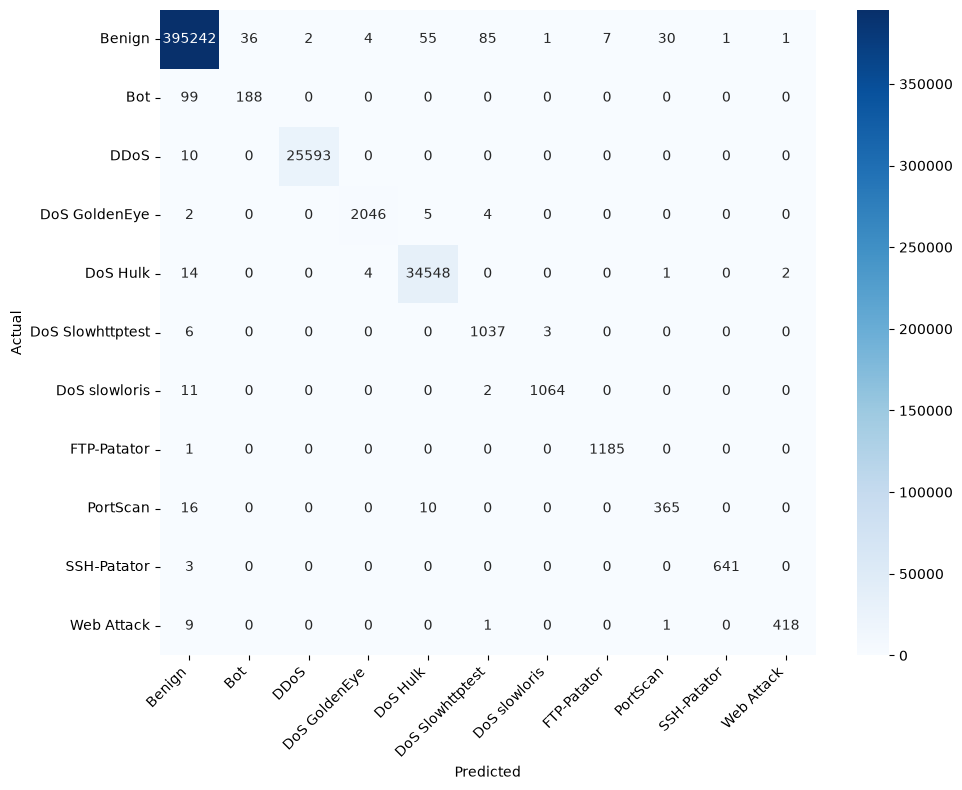

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../outputs/confusion_matrix.png')
plt.show()

In [13]:
import sys
print(sys.executable)

/Users/tavle/Desktop/trustsoc-ai/venv/bin/python


In [15]:
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_test, y_pred)
bot_idx = list(le.classes_).index('Bot')
bot_row = cm[bot_idx]

for i, count in enumerate(bot_row):
    if count > 0:
        print(f"True Bot → predicted {le.classes_[i]}: {count}")

True Bot → predicted Benign: 99
True Bot → predicted Bot: 188


In [16]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

model_weighted = xgb.XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    eval_metric='mlogloss', n_jobs=-1, random_state=42
)
model_weighted.fit(X_train, y_train, sample_weight=sample_weights)

y_pred_weighted = model_weighted.predict(X_test)
print(classification_report(y_test, y_pred_weighted, target_names=le.classes_))

                  precision    recall  f1-score   support

          Benign       1.00      1.00      1.00    395464
             Bot       0.42      1.00      0.59       287
            DDoS       1.00      1.00      1.00     25603
   DoS GoldenEye       0.98      1.00      0.99      2057
        DoS Hulk       1.00      1.00      1.00     34569
DoS Slowhttptest       0.91      0.99      0.95      1046
   DoS slowloris       0.98      0.99      0.99      1077
     FTP-Patator       0.99      1.00      1.00      1186
        PortScan       0.88      0.98      0.93       391
     SSH-Patator       1.00      1.00      1.00       644
      Web Attack       0.93      0.99      0.96       429

        accuracy                           1.00    462753
       macro avg       0.92      0.99      0.95    462753
    weighted avg       1.00      1.00      1.00    462753



In [17]:
bot_idx = list(le.classes_).index('Bot')
cm_weighted = confusion_matrix(y_test, y_pred_weighted)

# What's being misclassified AS Bot
predicted_bot_col = cm_weighted[:, bot_idx]
for i, count in enumerate(predicted_bot_col):
    if count > 0 and i != bot_idx:
        print(f"True {le.classes_[i]} → predicted Bot: {count}")

True Benign → predicted Bot: 394


In [18]:
for w in [3, 5, 8]:
    sample_weights_targeted = np.ones(len(y_train))
    bot_mask = (y_train == bot_idx)
    sample_weights_targeted[bot_mask] = w

    model_w = xgb.XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        eval_metric='mlogloss', n_jobs=-1, random_state=42
    )
    model_w.fit(X_train, y_train, sample_weight=sample_weights_targeted)
    y_pred_w = model_w.predict(X_test)

    from sklearn.metrics import precision_recall_fscore_support
    p, r, f1, _ = precision_recall_fscore_support(y_test, y_pred_w, labels=[bot_idx], average=None)
    print(f"weight={w}: Bot precision={p[0]:.2f}, recall={r[0]:.2f}, f1={f1[0]:.2f}")

weight=3: Bot precision=0.63, recall=0.93, f1=0.75
weight=5: Bot precision=0.61, recall=0.96, f1=0.75
weight=8: Bot precision=0.59, recall=0.96, f1=0.73


In [19]:
sample_weights_final = np.ones(len(y_train))
sample_weights_final[y_train == bot_idx] = 3

final_model = xgb.XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    eval_metric='mlogloss', n_jobs=-1, random_state=42
)
final_model.fit(X_train, y_train, sample_weight=sample_weights_final)

y_pred_final = final_model.predict(X_test)
print(classification_report(y_test, y_pred_final, target_names=le.classes_))

import joblib
joblib.dump(final_model, '../outputs/final_xgb_model.pkl')

                  precision    recall  f1-score   support

          Benign       1.00      1.00      1.00    395464
             Bot       0.63      0.93      0.75       287
            DDoS       1.00      1.00      1.00     25603
   DoS GoldenEye       1.00      1.00      1.00      2057
        DoS Hulk       1.00      1.00      1.00     34569
DoS Slowhttptest       0.92      0.99      0.95      1046
   DoS slowloris       0.99      0.99      0.99      1077
     FTP-Patator       0.99      1.00      1.00      1186
        PortScan       0.92      0.93      0.93       391
     SSH-Patator       1.00      1.00      1.00       644
      Web Attack       0.98      0.98      0.98       429

        accuracy                           1.00    462753
       macro avg       0.95      0.98      0.96    462753
    weighted avg       1.00      1.00      1.00    462753



['../outputs/final_xgb_model.pkl']

In [20]:
import shap
import time

explainer = shap.TreeExplainer(final_model)

start = time.time()
shap_values_sample = explainer.shap_values(X_test.iloc[:200])
print(f"SHAP computation took {time.time()-start:.1f}s for 200 rows")

SHAP computation took 0.1s for 200 rows


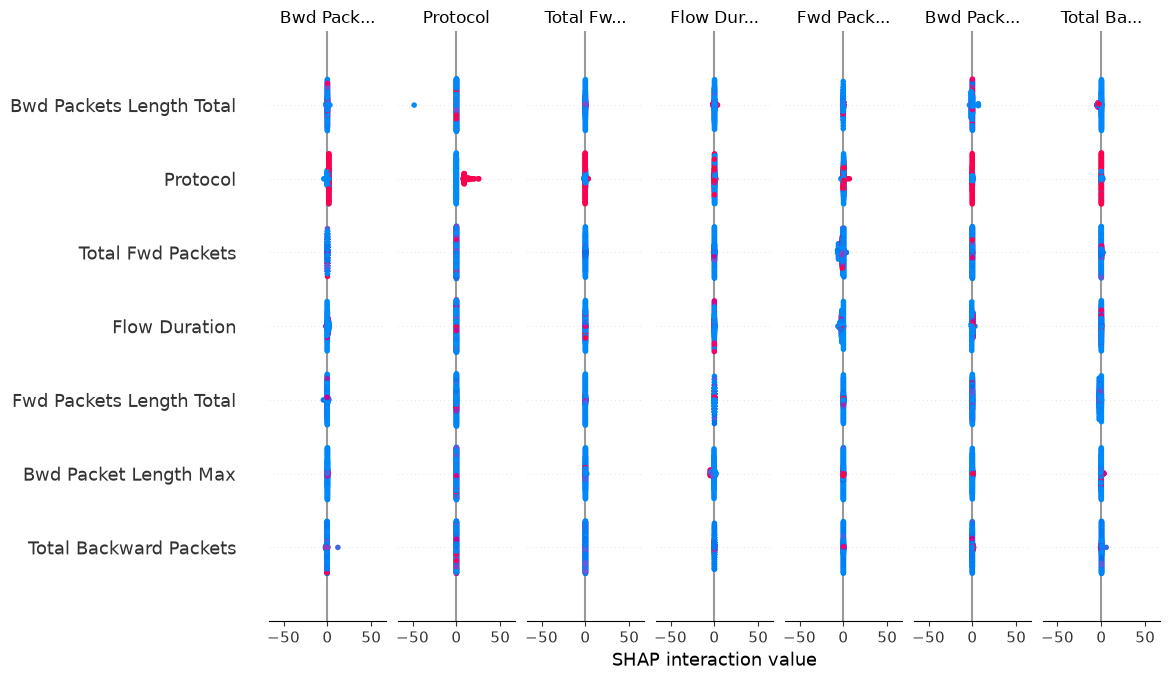

In [21]:
shap.summary_plot(shap_values_sample, X_test.iloc[:200], class_names=le.classes_)

In [22]:
print(type(shap_values_sample))
if isinstance(shap_values_sample, list):
    print(f"Number of classes: {len(shap_values_sample)}")
    print(f"Shape per class: {shap_values_sample[0].shape}")
else:
    print(f"Shape: {shap_values_sample.shape}")

<class 'numpy.ndarray'>
Shape: (200, 77, 11)


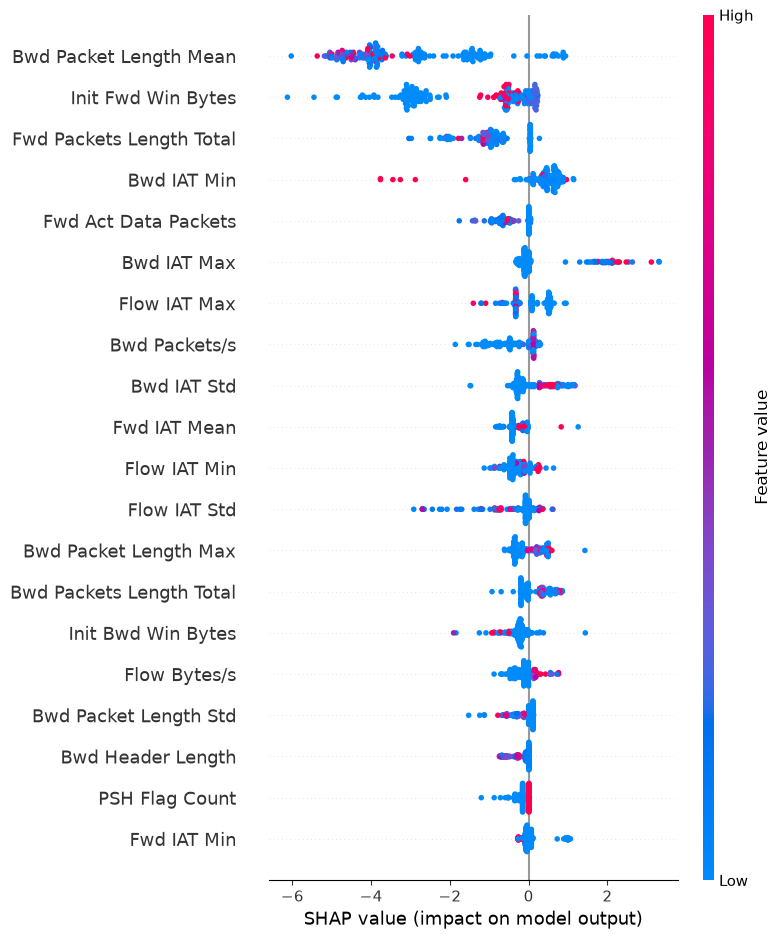

In [23]:
bot_idx = list(le.classes_).index('Bot')

shap.summary_plot(
    shap_values_sample[:, :, bot_idx],
    X_test.iloc[:200],
    feature_names=X.columns,
    show=True
)

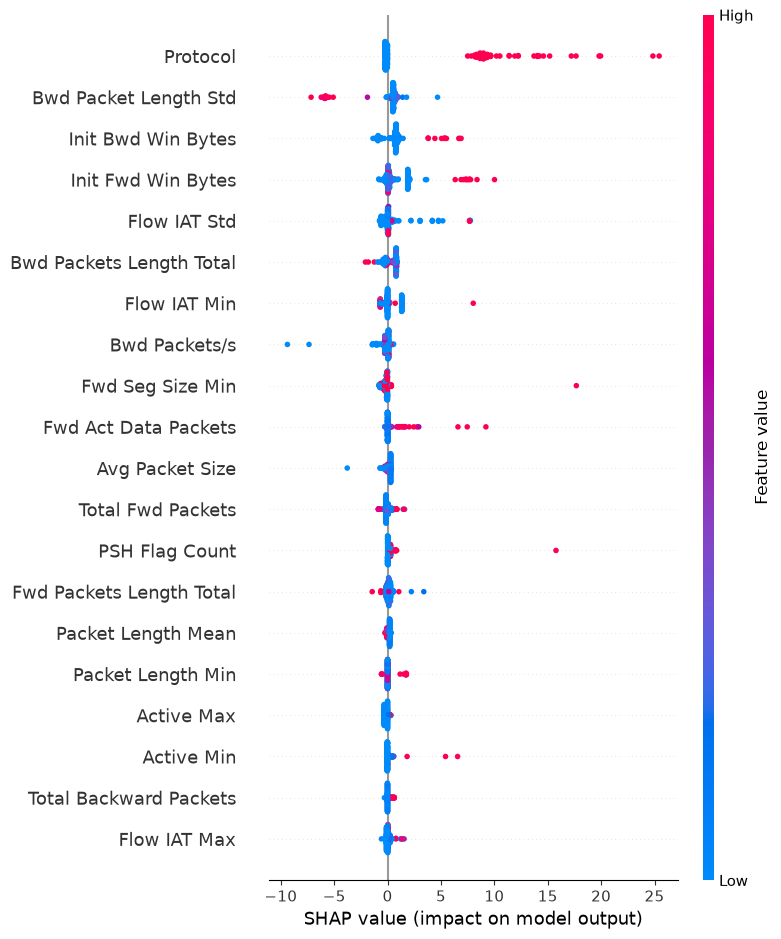

In [24]:
benign_idx = list(le.classes_).index('Benign')

shap.summary_plot(
    shap_values_sample[:, :, benign_idx],
    X_test.iloc[:200],
    feature_names=X.columns,
    show=True
)

In [25]:
start = time.time()
shap_values_full = explainer.shap_values(X_test)
print(f"Full test set SHAP took {time.time()-start:.1f}s for {len(X_test)} rows")

import joblib
joblib.dump(shap_values_full, '../outputs/shap_values_full.pkl')

Full test set SHAP took 130.3s for 462753 rows


['../outputs/shap_values_full.pkl']

In [26]:
import numpy as np

def explain_flow(idx, X_test, y_pred, shap_values_full, le, top_k=5):
    pred_class_idx = y_pred[idx]
    pred_class_name = le.classes_[pred_class_idx]
    
    # SHAP values for this row, for the predicted class
    row_shap = shap_values_full[idx, :, pred_class_idx]
    row_features = X_test.iloc[idx]
    
    # Rank by absolute SHAP contribution
    top_indices = np.argsort(np.abs(row_shap))[::-1][:top_k]
    
    top_features = [
        {
            "feature": X_test.columns[i],
            "value": float(row_features.iloc[i]),
            "shap_value": float(row_shap[i])
        }
        for i in top_indices
    ]
    
    return {
        "flow_id": int(idx),
        "predicted_class": pred_class_name,
        "top_shap_features": top_features
    }

# Test it on a few flows, including at least one Bot prediction
sample_explanations = [explain_flow(i, X_test.reset_index(drop=True), y_pred_final, shap_values_full, le) 
                        for i in range(5)]

import json
with open('../outputs/sample_flow_explanations.json', 'w') as f:
    json.dump(sample_explanations, f, indent=2)

print(json.dumps(sample_explanations, indent=2))

[
  {
    "flow_id": 0,
    "predicted_class": "DoS Hulk",
    "top_shap_features": [
      {
        "feature": "Init Fwd Win Bytes",
        "value": 274.0,
        "shap_value": 1.9294549226760864
      },
      {
        "feature": "Packet Length Mean",
        "value": 0.0,
        "shap_value": 1.7004743814468384
      },
      {
        "feature": "Init Bwd Win Bytes",
        "value": -1.0,
        "shap_value": -0.4012897312641144
      },
      {
        "feature": "Fwd IAT Total",
        "value": 1029.0,
        "shap_value": 0.3341970145702362
      },
      {
        "feature": "Flow IAT Max",
        "value": 1029.0,
        "shap_value": 0.2831396162509918
      }
    ]
  },
  {
    "flow_id": 1,
    "predicted_class": "Benign",
    "top_shap_features": [
      {
        "feature": "Protocol",
        "value": 17.0,
        "shap_value": 9.01319408416748
      },
      {
        "feature": "Init Fwd Win Bytes",
        "value": -1.0,
        "shap_value": 1.892590165138

In [27]:
bot_indices = np.where(y_pred_final == bot_idx)[0]
print(bot_indices[:10])

[  712  6482  8030  9234  9380 11216 11389 12523 12802 14170]


In [28]:
bot_example = explain_flow(
    bot_indices[0],
    X_test.reset_index(drop=True),
    y_pred_final,
    shap_values_full,
    le
)

print(json.dumps(bot_example, indent=2))

{
  "flow_id": 712,
  "predicted_class": "Bot",
  "top_shap_features": [
    {
      "feature": "Bwd IAT Min",
      "value": 561.0,
      "shap_value": 7.305907726287842
    },
    {
      "feature": "Bwd IAT Std",
      "value": 42071.4375,
      "shap_value": 6.073697090148926
    },
    {
      "feature": "Flow IAT Max",
      "value": 60059.0,
      "shap_value": 6.029270648956299
    },
    {
      "feature": "Bwd Packet Length Max",
      "value": 128.0,
      "shap_value": 4.871198654174805
    },
    {
      "feature": "Packet Length Max",
      "value": 198.0,
      "shap_value": 3.4520602226257324
    }
  ]
}


In [29]:
# How much does Protocol alone predict the label?
print(df_model.groupby('Label')['Protocol'].value_counts(normalize=True))

Label             Protocol
Benign            6           0.519337
                  17          0.479863
                  0           0.000801
Bot               6           1.000000
DDoS              6           1.000000
DoS GoldenEye     6           1.000000
DoS Hulk          6           1.000000
DoS Slowhttptest  6           1.000000
DoS slowloris     6           1.000000
FTP-Patator       6           1.000000
PortScan          6           0.996421
                  0           0.003067
                  17          0.000511
SSH-Patator       6           1.000000
Web Attack        6           1.000000
Name: proportion, dtype: float64


In [30]:
# Generate a batch of sample explanations across different classes for Person 2 to design prompts against
import random
sample_indices = random.sample(range(len(X_test)), 20)
handoff_examples = [explain_flow(i, X_test.reset_index(drop=True), y_pred_final, shap_values_full, le) for i in sample_indices]

with open('../outputs/handoff_examples.json', 'w') as f:
    json.dump(handoff_examples, f, indent=2)

In [31]:
y_pred_proba_final = final_model.predict_proba(X_test)

In [32]:
def explain_flow(idx, X_test, y_pred, y_pred_proba, shap_values_full, le, top_k=5):
    pred_class_idx = y_pred[idx]
    pred_class_name = le.classes_[pred_class_idx]
    confidence = float(y_pred_proba[idx, pred_class_idx])
    
    row_shap = shap_values_full[idx, :, pred_class_idx]
    row_features = X_test.iloc[idx]
    
    top_indices = np.argsort(np.abs(row_shap))[::-1][:top_k]
    top_features = [
        {
            "feature": X_test.columns[i],
            "value": float(row_features.iloc[i]),
            "shap_value": float(row_shap[i])
        }
        for i in top_indices
    ]
    
    return {
        "flow_id": int(idx),
        "predicted_class": pred_class_name,
        "confidence": confidence,
        "top_shap_features": top_features
    }

In [33]:
sample_indices = random.sample(range(len(X_test)), 20)
handoff_examples = [
    explain_flow(i, X_test.reset_index(drop=True), y_pred_final, y_pred_proba_final, shap_values_full, le) 
    for i in sample_indices
]
with open('../outputs/handoff_examples.json', 'w') as f:
    json.dump(handoff_examples, f, indent=2)

In [36]:
import pandas as pd
import numpy as np
# Load your saved test set + labels
X_test = pd.read_pickle('outputs/X_test.pkl') if os.path.exists('outputs/X_test.pkl') else None
# If you didn't save X_test/y_test separately, reload from train.py's split logic instead

# Get predictions to know which rows are which class
y_pred = final_model.predict(X_test)
class_names = le.classes_

demo_indices = []
for cls in ['DDoS', 'SSH-Patator', 'Bot', 'Bot', 'Benign', 'PortScan']:
    cls_idx = list(class_names).index(cls)
    matching = np.where(y_pred == cls_idx)[0]
    demo_indices.append(np.random.choice(matching))

demo_df = X_test.iloc[demo_indices].reset_index(drop=True)
demo_df.to_csv('outputs/demo_sample.csv', index=False)
print(demo_df.shape)

TypeError: Not supported type for data.<class 'NoneType'>

In [38]:
import pandas as pd
import numpy as np
import glob
from sklearn.model_selection import train_test_split
import joblib

files = glob.glob("../data/raw/*.parquet")
dfs = [pd.read_parquet(f) for f in files]
df = pd.concat(dfs, ignore_index=True)

# Fix garbled encoding FIRST
df['Label'] = df['Label'].str.replace('Web Attack \ufffd', 'Web Attack -', regex=False)
df['Label'] = df['Label'].str.strip()

# Then merge Web Attack subtypes
web_attack_labels = ['Web Attack - Brute Force', 'Web Attack - XSS', 'Web Attack - Sql Injection']
df['Label'] = df['Label'].apply(lambda x: 'Web Attack' if x in web_attack_labels else x)

exclude_labels = ['Heartbleed', 'Infiltration']
df_model = df[~df['Label'].isin(exclude_labels)].copy()

le = joblib.load('../outputs/label_encoder.pkl')
y = le.transform(df_model['Label'])
X = df_model.drop(columns=['Label'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

final_model = joblib.load('../outputs/final_xgb_model.pkl')
print(X_test.shape)

(462753, 77)


In [39]:
def load_and_clean_data(raw_dir="../data/raw"):
    files = glob.glob(f"{raw_dir}/*.parquet")
    dfs = [pd.read_parquet(f) for f in files]
    df = pd.concat(dfs, ignore_index=True)

    df['Label'] = df['Label'].str.replace('Web Attack \ufffd', 'Web Attack -', regex=False)
    df['Label'] = df['Label'].str.strip()

    web_attack_labels = ['Web Attack - Brute Force', 'Web Attack - XSS', 'Web Attack - Sql Injection']
    df['Label'] = df['Label'].apply(lambda x: 'Web Attack' if x in web_attack_labels else x)

    exclude_labels = ['Heartbleed', 'Infiltration']
    df_model = df[~df['Label'].isin(exclude_labels)].copy()
    return df_model

In [40]:
from sklearn.metrics import classification_report
import joblib

model = joblib.load('outputs/final_xgb_model.pkl')
le = joblib.load('outputs/label_encoder.pkl')
X_test = joblib.load('outputs/X_test.pkl')
y_test = joblib.load('outputs/y_test.pkl')

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=le.classes_))

FileNotFoundError: [Errno 2] No such file or directory: 'outputs/final_xgb_model.pkl'

In [41]:
from sklearn.metrics import classification_report
import joblib

model = joblib.load('../outputs/final_xgb_model.pkl')
le = joblib.load('../outputs/label_encoder.pkl')
X_test = joblib.load('../outputs/X_test.pkl')
y_test = joblib.load('../outputs/y_test.pkl')

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=le.classes_))

                  precision    recall  f1-score   support

          Benign       1.00      1.00      1.00    395464
             Bot       0.63      0.93      0.75       287
            DDoS       1.00      1.00      1.00     25603
   DoS GoldenEye       1.00      1.00      1.00      2057
        DoS Hulk       1.00      1.00      1.00     34569
DoS Slowhttptest       0.92      0.99      0.95      1046
   DoS slowloris       0.99      0.99      0.99      1077
     FTP-Patator       0.99      1.00      1.00      1186
        PortScan       0.92      0.93      0.93       391
     SSH-Patator       1.00      1.00      1.00       644
      Web Attack       0.98      0.98      0.98       429

        accuracy                           1.00    462753
       macro avg       0.95      0.98      0.96    462753
    weighted avg       1.00      1.00      1.00    462753



In [42]:
X_test = joblib.load('outputs/X_test.pkl')
y_test = joblib.load('outputs/y_test.pkl')

FileNotFoundError: [Errno 2] No such file or directory: 'outputs/X_test.pkl'

In [43]:
X_test = joblib.load('../outputs/X_test.pkl')
y_test = joblib.load('../outputs/y_test.pkl')

In [44]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=le.classes_))

                  precision    recall  f1-score   support

          Benign       1.00      1.00      1.00    395464
             Bot       0.63      0.93      0.75       287
            DDoS       1.00      1.00      1.00     25603
   DoS GoldenEye       1.00      1.00      1.00      2057
        DoS Hulk       1.00      1.00      1.00     34569
DoS Slowhttptest       0.92      0.99      0.95      1046
   DoS slowloris       0.99      0.99      0.99      1077
     FTP-Patator       0.99      1.00      1.00      1186
        PortScan       0.92      0.93      0.93       391
     SSH-Patator       1.00      1.00      1.00       644
      Web Attack       0.98      0.98      0.98       429

        accuracy                           1.00    462753
       macro avg       0.95      0.98      0.96    462753
    weighted avg       1.00      1.00      1.00    462753



In [45]:
class_names = le.classes_
demo_indices = []
for cls in ['DDoS', 'SSH-Patator', 'Bot', 'Bot', 'Benign', 'PortScan']:
    cls_idx = list(class_names).index(cls)
    matching = np.where(y_pred == cls_idx)[0]
    demo_indices.append(np.random.choice(matching))

demo_df = X_test.iloc[demo_indices].reset_index(drop=True)
demo_df.to_csv('../outputs/demo_sample.csv', index=False)
print(demo_df.shape)
demo_df.head()

(6, 77)


,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Act Data Packets,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
0,6,8696994,7,4,50,11607,20,0,7.142857,6.094494,...,5,20,182990.0,0.0,182990,182990,7985840.0,0.00,7985840,7985840
1,6,65249005,32,49,10316,2115,992,0,322.375000,443.509216,...,19,20,5126889.5,7063676.5,10100000,132116,27400000.0,3462409.75,29900000,25000000
2,6,63794,4,3,207,134,195,0,51.750000,95.541878,...,3,20,0.0,0.0,0,0,0.0,0.00,0,0
3,6,1044192,3,3,0,18,0,0,0.000000,0.000000,...,0,28,0.0,0.0,0,0,0.0,0.00,0,0
4,6,1222723,6,8,733,572,437,0,122.166664,176.571136,...,3,20,0.0,0.0,0,0,0.0,0.00,0,0


In [47]:
import os
print(os.getcwd())

/Users/tavle/Desktop/trustsoc-ai/notebooks


In [51]:
import pickle
from sklearn.metrics import classification_report, accuracy_score

model = pickle.load(open('../outputs/final_xgb_model.pkl', 'rb'))
X_test = pickle.load(open('../outputs/X_test.pkl', 'rb'))
y_test = pickle.load(open('../outputs/y_test.pkl', 'rb'))

y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=4))

UnpicklingError: invalid load key, '\x0a'.

In [52]:
with open('../outputs/X_test.pkl', 'r', errors='replace') as f:
    print(f.read(200))

��Z      �pandas��	DataFrame���)��}�(�_mgr��pandas.core.internals.managers��BlockManager���(�pandas._libs.internals��_unpickle_block����joblib.numpy_pickle��NumpyArrayWrapper���)��}�(subcl


In [53]:
import joblib
from sklearn.metrics import classification_report, accuracy_score

model = joblib.load('../outputs/final_xgb_model.pkl')
X_test = joblib.load('../outputs/X_test.pkl')
y_test = joblib.load('../outputs/y_test.pkl')

y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=4))

0.9989756954574038
              precision    recall  f1-score   support

           0     0.9998    0.9991    0.9994    395464
           1     0.6276    0.9338    0.7507       287
           2     0.9999    0.9996    0.9998     25603
           3     0.9956    0.9966    0.9961      2057
           4     0.9980    0.9993    0.9987     34569
           5     0.9184    0.9904    0.9531      1046
           6     0.9935    0.9889    0.9912      1077
           7     0.9950    0.9983    0.9966      1186
           8     0.9237    0.9284    0.9260       391
           9     0.9984    0.9953    0.9969       644
          10     0.9836    0.9767    0.9801       429

    accuracy                         0.9990    462753
   macro avg     0.9485    0.9824    0.9626    462753
weighted avg     0.9991    0.9990    0.9990    462753

